<a href="https://colab.research.google.com/github/leo-aguiar/vivo_customer_churn_prediction/blob/main/vivo_customer_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Versão do R
R.version.string

[1] "R version 4.6.1 (2026-06-24)"

In [4]:
# Pacotes necessarios - instalação
install.packages('tidyverse') # manipulação de dados
install.packages('ggplot2') # visualização
install.packages('cowplot') # visualização - unir gráficos
install.packages('caret') # modelos estatísticos
install.packages('corrplot') # matriz de correlação
install.packages("rattle") # visualização da árvore de decição

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [5]:
# chamando os pacotes ja instalados
library(caret)
library(tidyverse)
library(ggplot2)
library(cowplot)
library(corrplot)
library(rattle)

In [6]:
# carregando dados para o Data Frame (dados)
dados <-read.csv("vivo_churn.csv", stringsAsFactors = T)

In [7]:
# Visualização dos dados
glimpse(dados)
summary(dados)

Rows: 7,043
Columns: 21
$ customerID       <fct> 7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOCW, 9237-…
$ gender           <fct> Female, Male, Male, Male, Female, Female, Male, Femal…
$ SeniorCitizen    <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ Partner          <fct> Yes, No, No, No, No, No, No, No, Yes, No, Yes, No, Ye…
$ Dependents       <fct> No, No, No, No, No, No, Yes, No, No, Yes, Yes, No, No…
$ tenure           <int> 1, 34, 2, 45, 2, 8, 22, 10, 28, 62, 13, 16, 58, 49, 2…
$ PhoneService     <fct> No, Yes, Yes, No, Yes, Yes, Yes, No, Yes, Yes, Yes, Y…
$ MultipleLines    <fct> No phone service, No, No, No phone service, No, Yes, …
$ InternetService  <fct> DSL, DSL, DSL, DSL, Fiber optic, Fiber optic, Fiber o…
$ OnlineSecurity   <fct> No, Yes, Yes, Yes, No, No, No, Yes, No, Yes, Yes, No …
$ OnlineBackup     <fct> Yes, No, Yes, No, No, No, Yes, No, No, Yes, No, No in…
$ DeviceProtection <fct> No, Yes, No, Yes, No, Yes, No, No, Yes, No, No, No in…
$ TechSupport   

      customerID      gender     SeniorCitizen    Partner    Dependents
 0002-ORFBO:   1   Female:3488   Min.   :0.0000   No :3641   No :4933  
 0003-MKNFE:   1   Male  :3555   1st Qu.:0.0000   Yes:3402   Yes:2110  
 0004-TLHLJ:   1                 Median :0.0000                        
 0011-IGKFF:   1                 Mean   :0.1621                        
 0013-EXCHZ:   1                 3rd Qu.:0.0000                        
 0013-MHZWF:   1                 Max.   :1.0000                        
 (Other)   :7037                                                       
     tenure      PhoneService          MultipleLines     InternetService
 Min.   : 0.00   No : 682     No              :3390   DSL        :2421  
 1st Qu.: 9.00   Yes:6361     No phone service: 682   Fiber optic:3096  
 Median :29.00                Yes             :2971   No         :1526  
 Mean   :32.37                                                          
 3rd Qu.:55.00                                             

In [8]:
# Check dados faltantes e retirar
colSums(is.na(dados)) #se nulo
dados_1 <- dados[!is.na(dados$TotalCharges),]
# diferente de nulo para o novo data frame (dados_1)
colSums(is.na(dados_1))
glimpse(dados_1)

customerID           gender    SeniorCitizen          Partner 
               0                0                0                0 
      Dependents           tenure     PhoneService    MultipleLines 
               0                0                0                0 
 InternetService   OnlineSecurity     OnlineBackup DeviceProtection 
               0                0                0                0 
     TechSupport      StreamingTV  StreamingMovies         Contract 
               0                0                0                0 
PaperlessBilling    PaymentMethod   MonthlyCharges     TotalCharges 
               0                0                0               11 
           Churn 
               0

customerID           gender    SeniorCitizen          Partner 
               0                0                0                0 
      Dependents           tenure     PhoneService    MultipleLines 
               0                0                0                0 
 InternetService   OnlineSecurity     OnlineBackup DeviceProtection 
               0                0                0                0 
     TechSupport      StreamingTV  StreamingMovies         Contract 
               0                0                0                0 
PaperlessBilling    PaymentMethod   MonthlyCharges     TotalCharges 
               0                0                0                0 
           Churn 
               0

Rows: 7,032
Columns: 21
$ customerID       <fct> 7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOCW, 9237-…
$ gender           <fct> Female, Male, Male, Male, Female, Female, Male, Femal…
$ SeniorCitizen    <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ Partner          <fct> Yes, No, No, No, No, No, No, No, Yes, No, Yes, No, Ye…
$ Dependents       <fct> No, No, No, No, No, No, Yes, No, No, Yes, Yes, No, No…
$ tenure           <int> 1, 34, 2, 45, 2, 8, 22, 10, 28, 62, 13, 16, 58, 49, 2…
$ PhoneService     <fct> No, Yes, Yes, No, Yes, Yes, Yes, No, Yes, Yes, Yes, Y…
$ MultipleLines    <fct> No phone service, No, No, No phone service, No, Yes, …
$ InternetService  <fct> DSL, DSL, DSL, DSL, Fiber optic, Fiber optic, Fiber o…
$ OnlineSecurity   <fct> No, Yes, Yes, Yes, No, No, No, Yes, No, Yes, Yes, No …
$ OnlineBackup     <fct> Yes, No, Yes, No, No, No, Yes, No, No, Yes, No, No in…
$ DeviceProtection <fct> No, Yes, No, Yes, No, Yes, No, No, Yes, No, No, No in…
$ TechSupport   

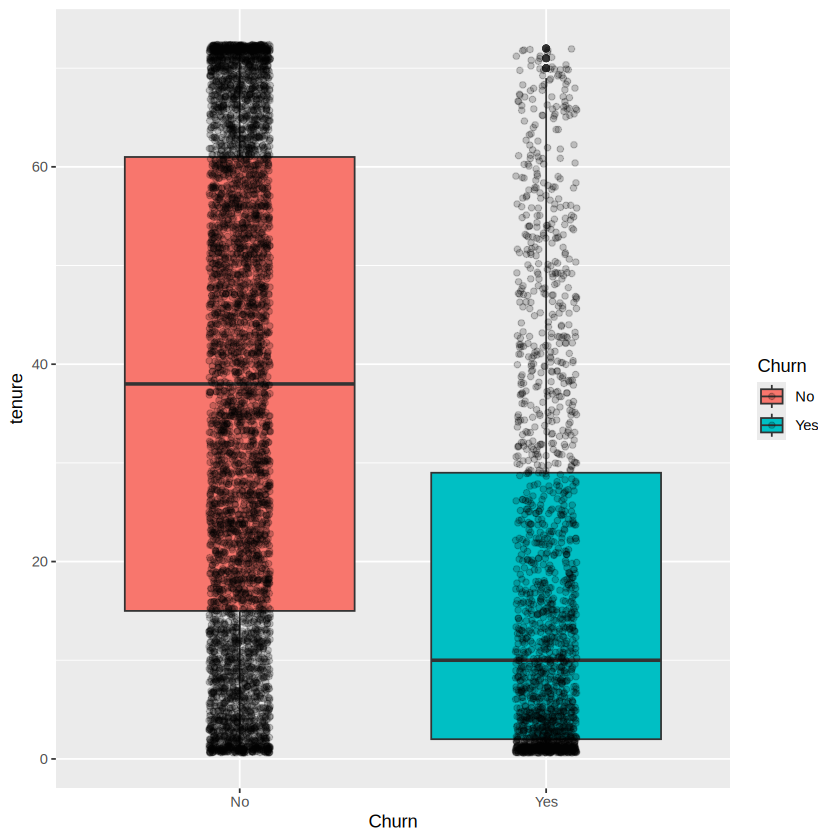

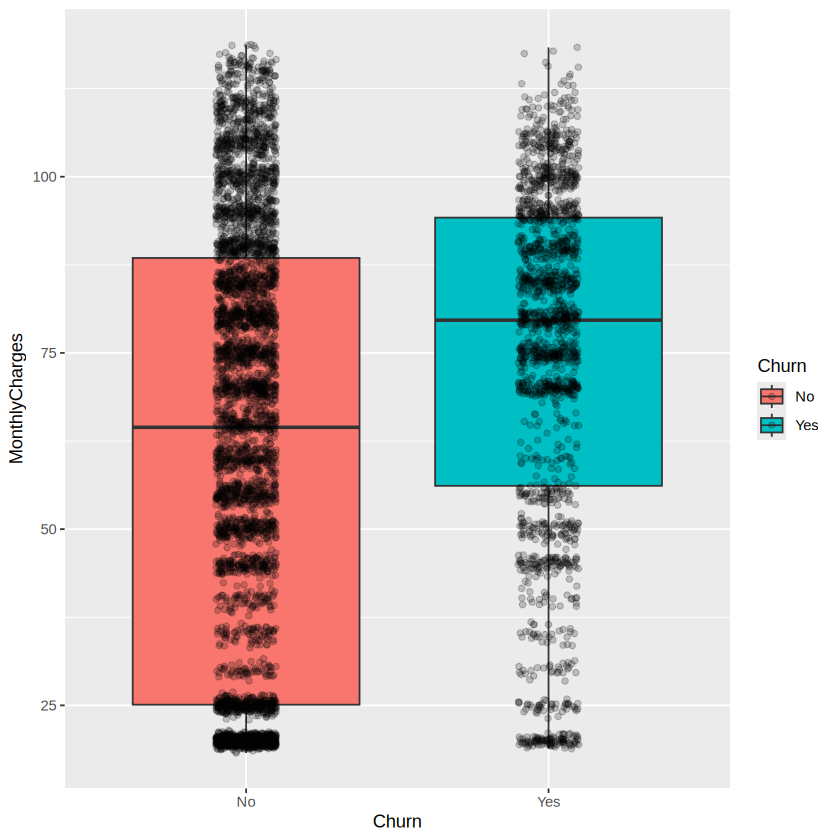

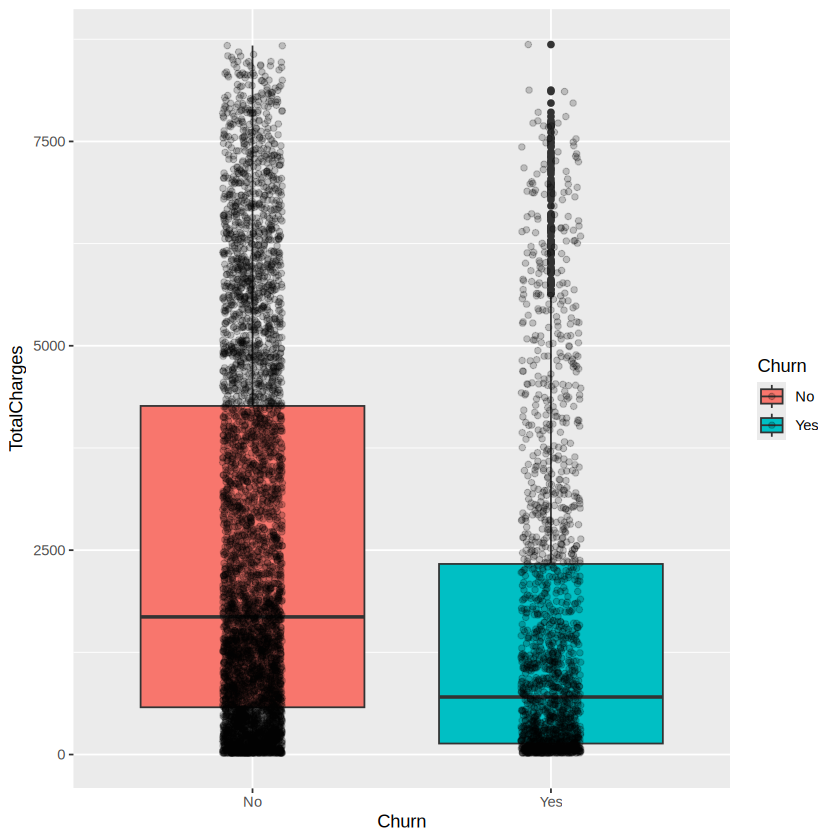

In [9]:
# outliers - visualizar dispersão dos dados via boxplot
dados_1 %>%
ggplot(aes(x=Churn,y=tenure, fill=Churn)) +
geom_boxplot() + geom_jitter(width=0.1,alpha=0.2)

dados_1 %>%
ggplot(aes(x=Churn,y=MonthlyCharges, fill=Churn)) +
geom_boxplot() + geom_jitter(width=0.1,alpha=0.2)
dados_1 %>%

ggplot(aes(x=Churn,y=TotalCharges, fill=Churn)) +
geom_boxplot() + geom_jitter(width=0.1,alpha=0.2)

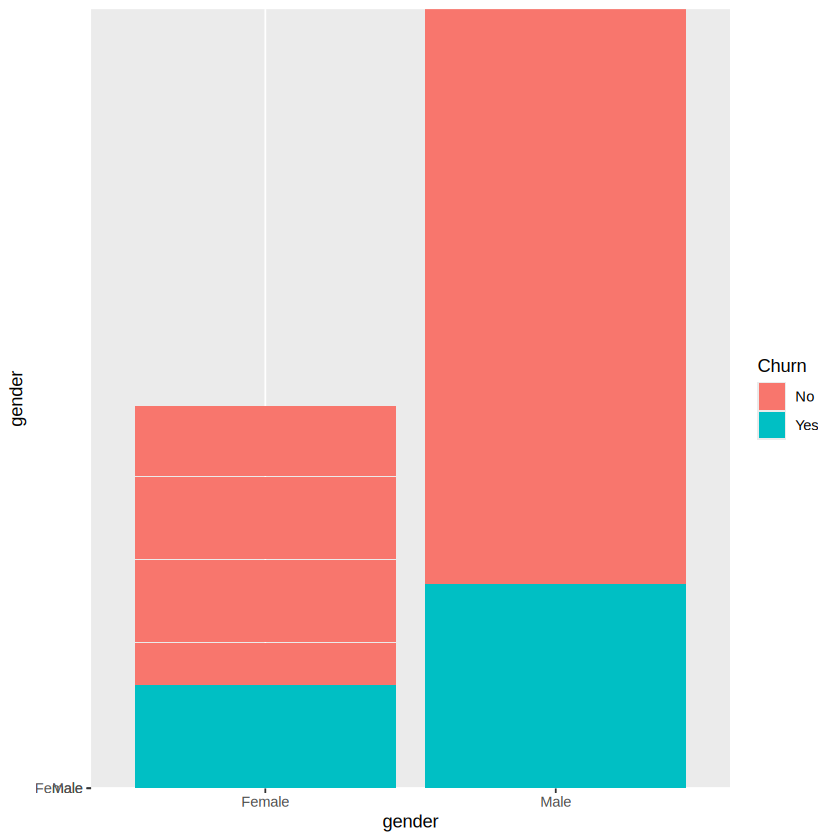

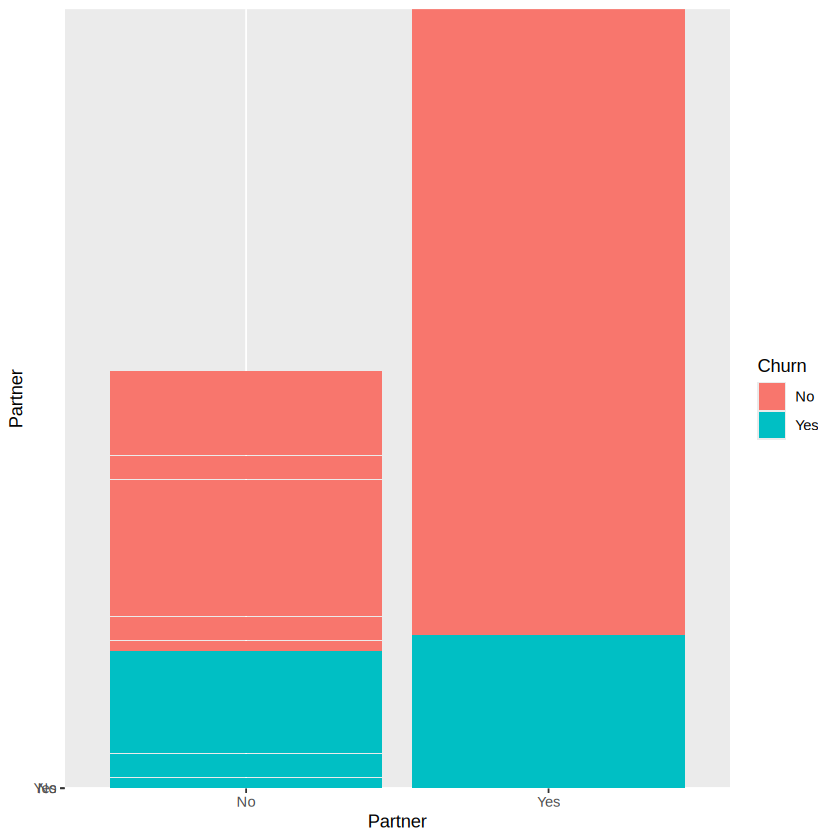

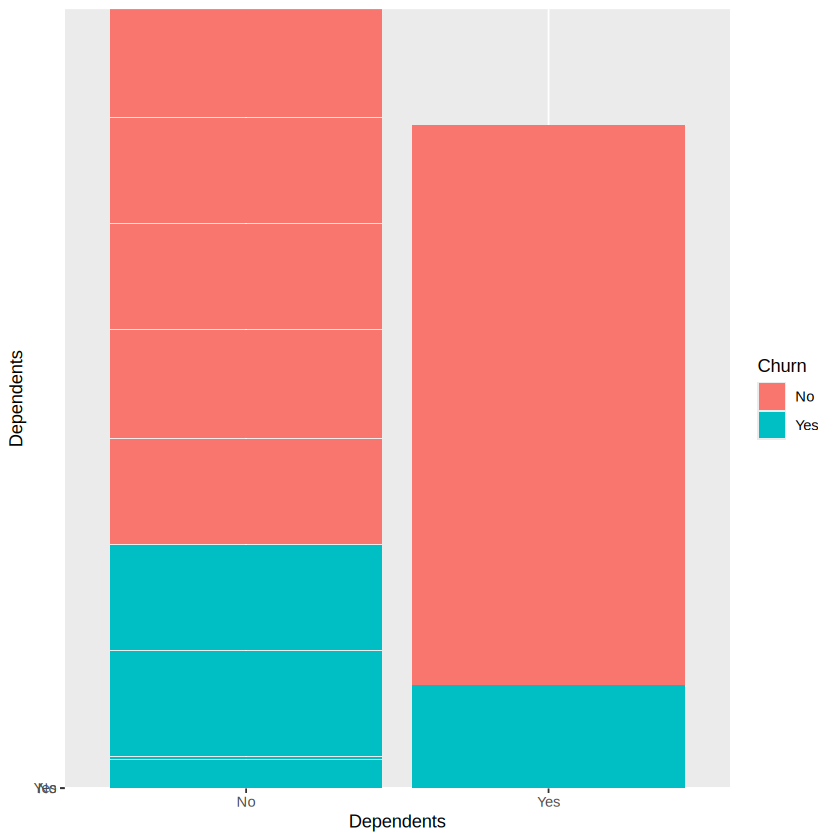

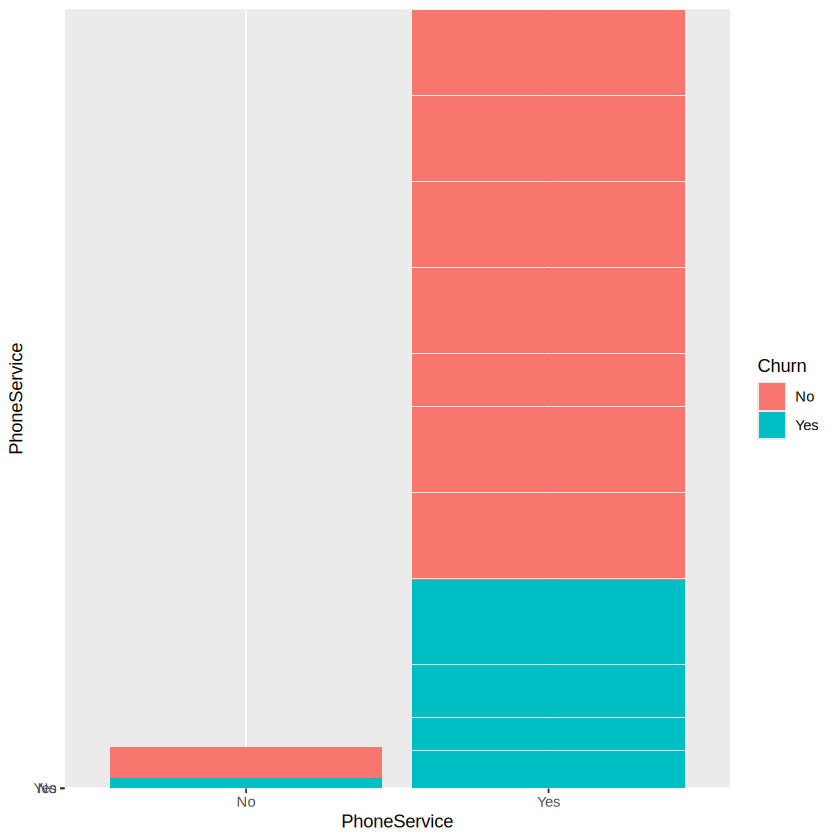

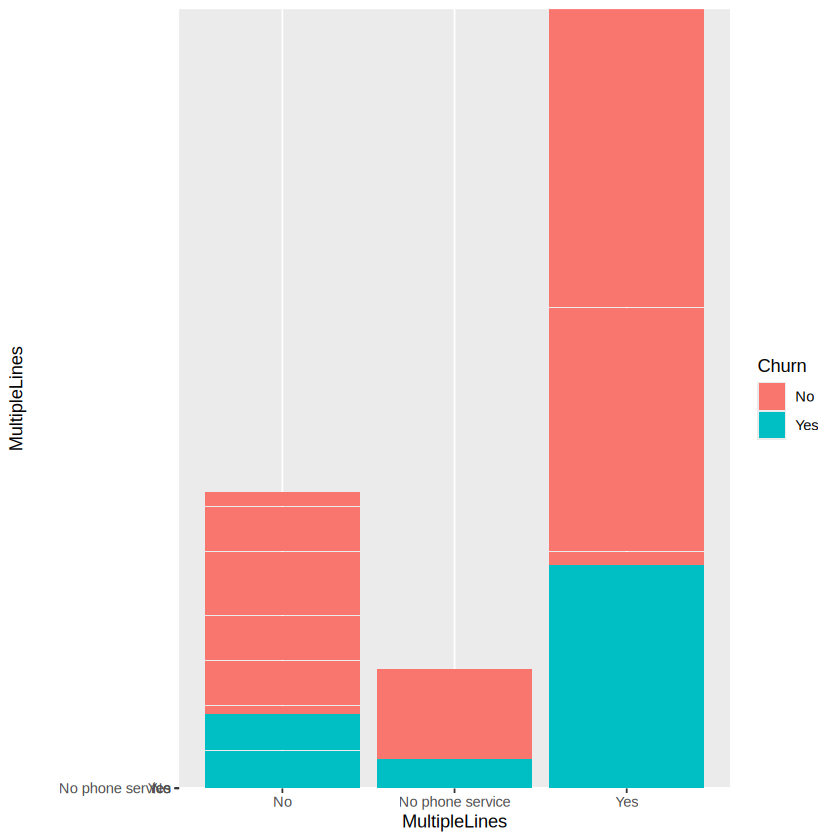

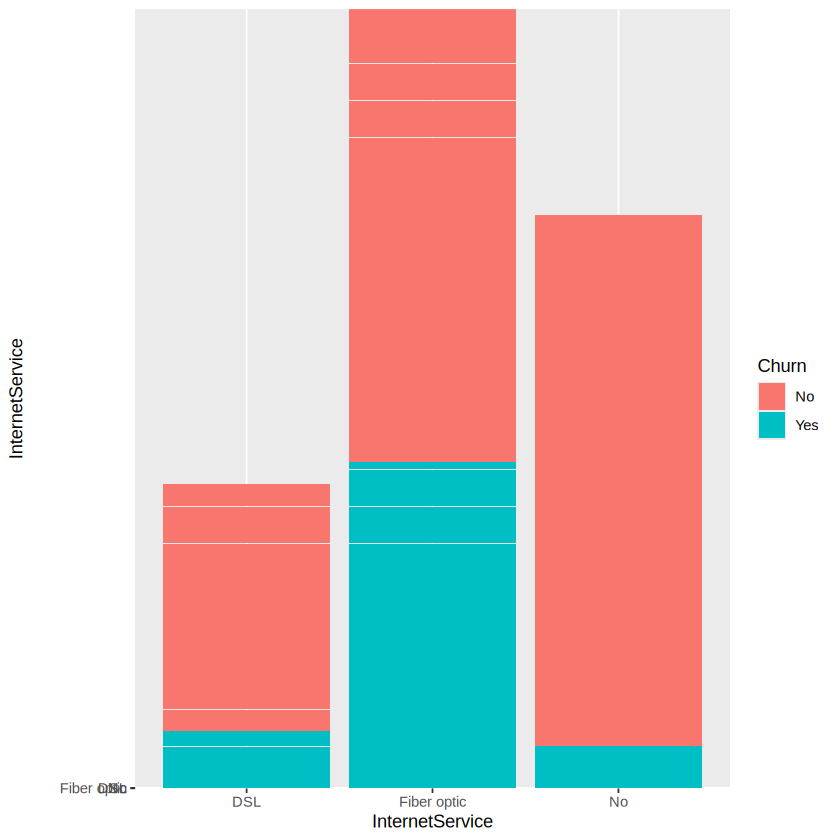

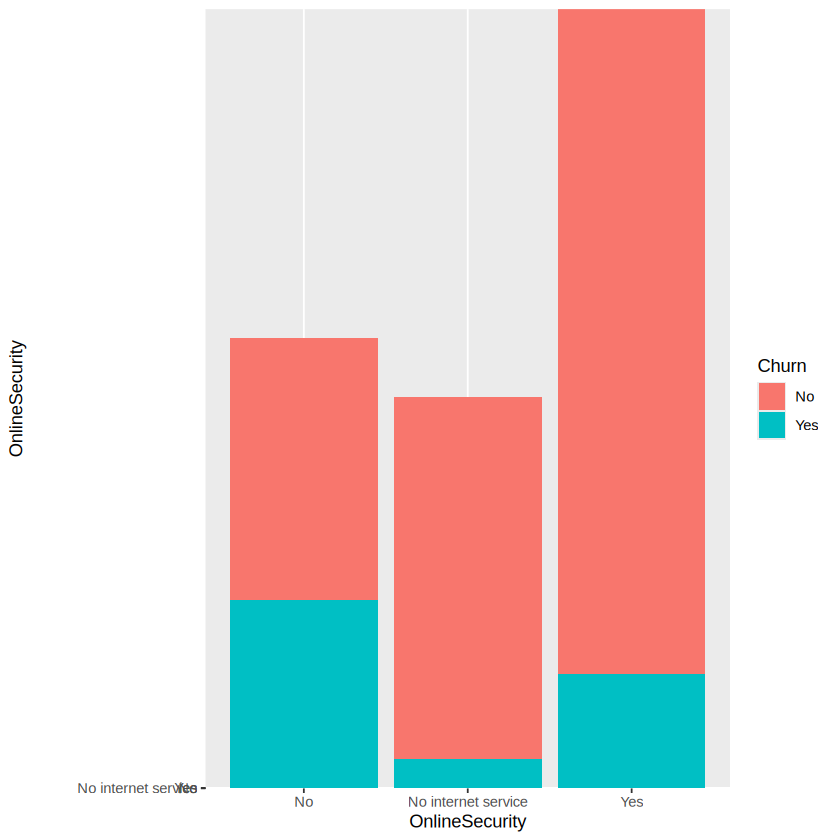

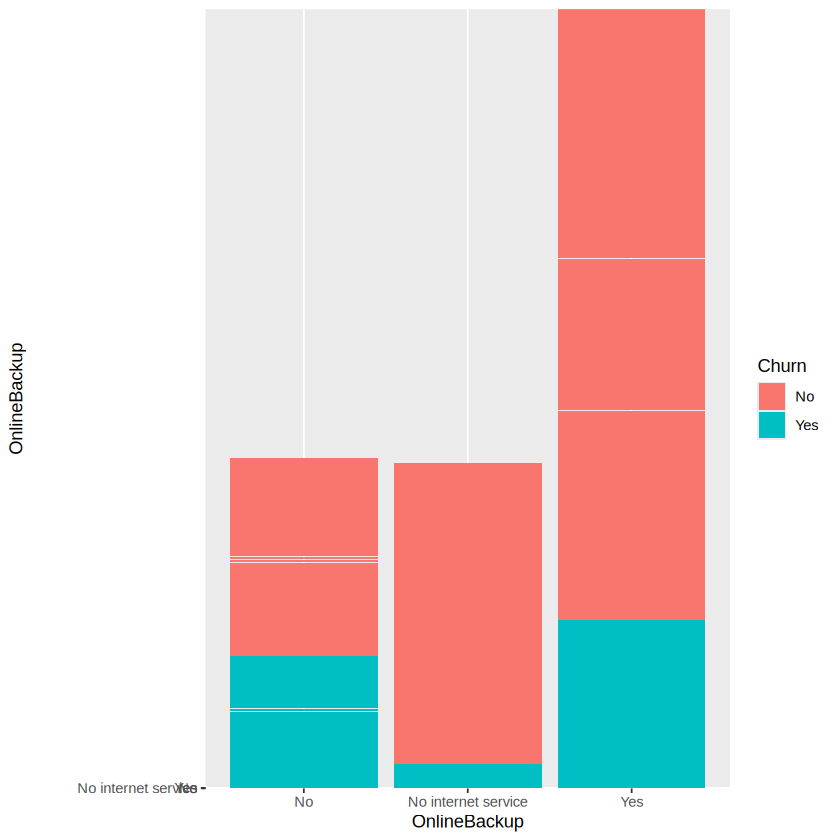

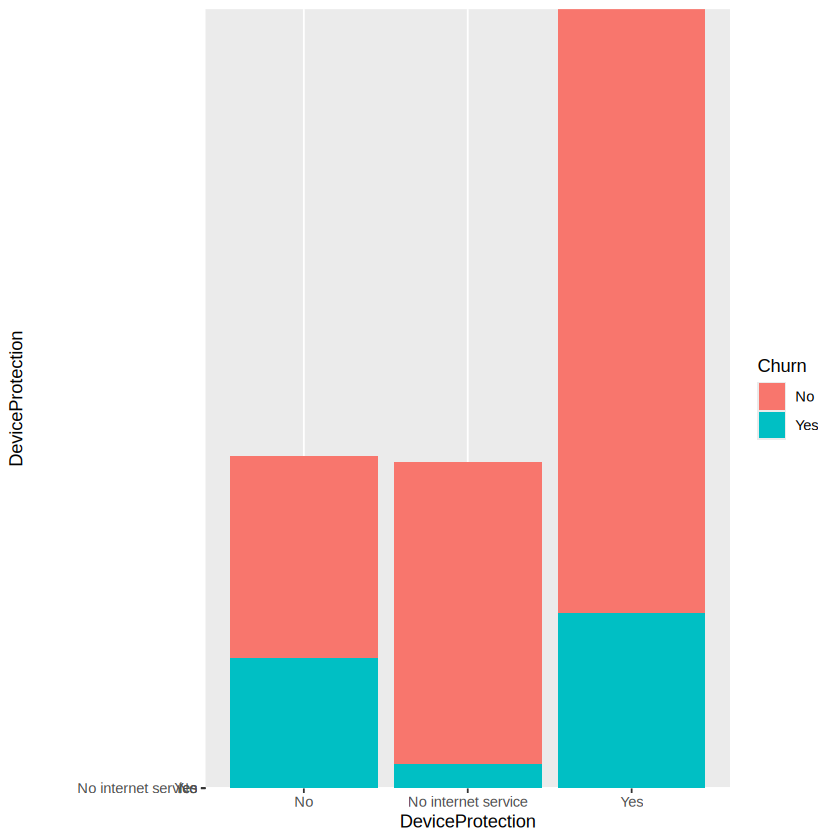

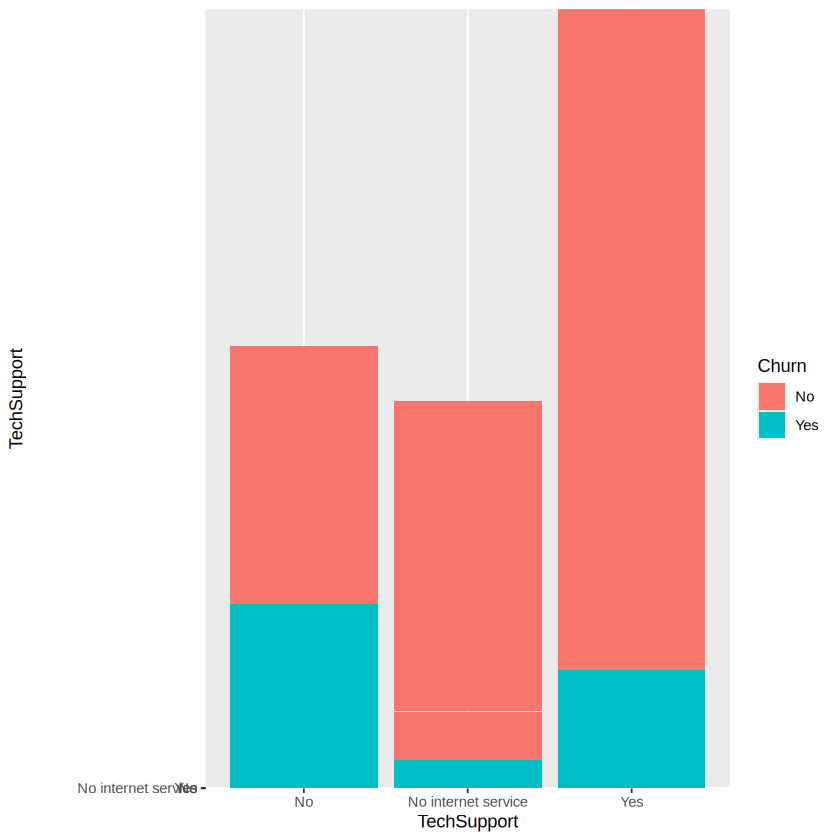

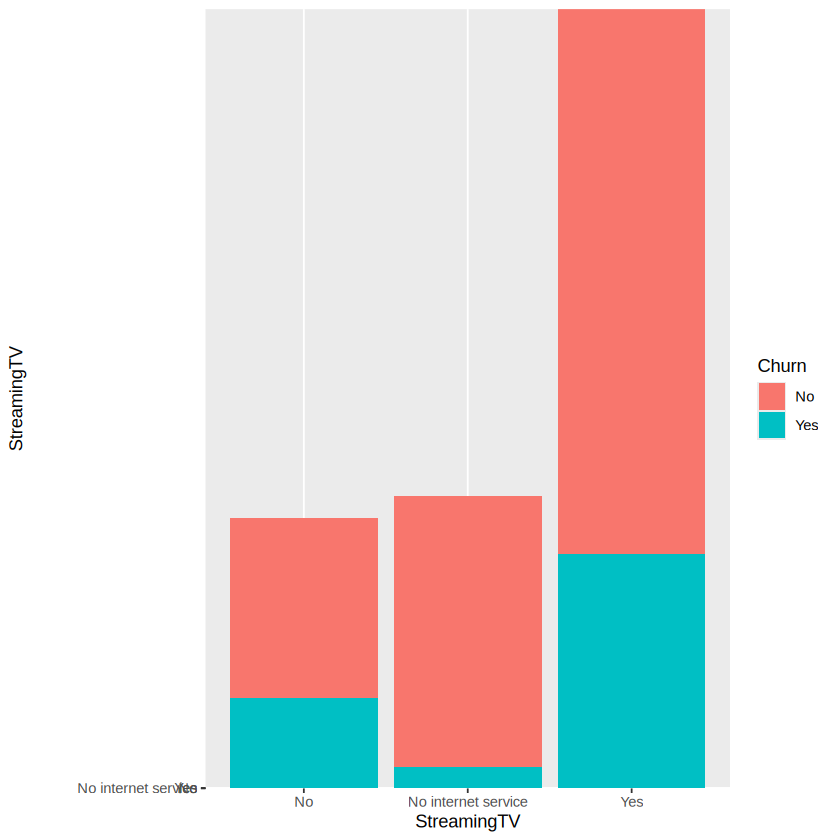

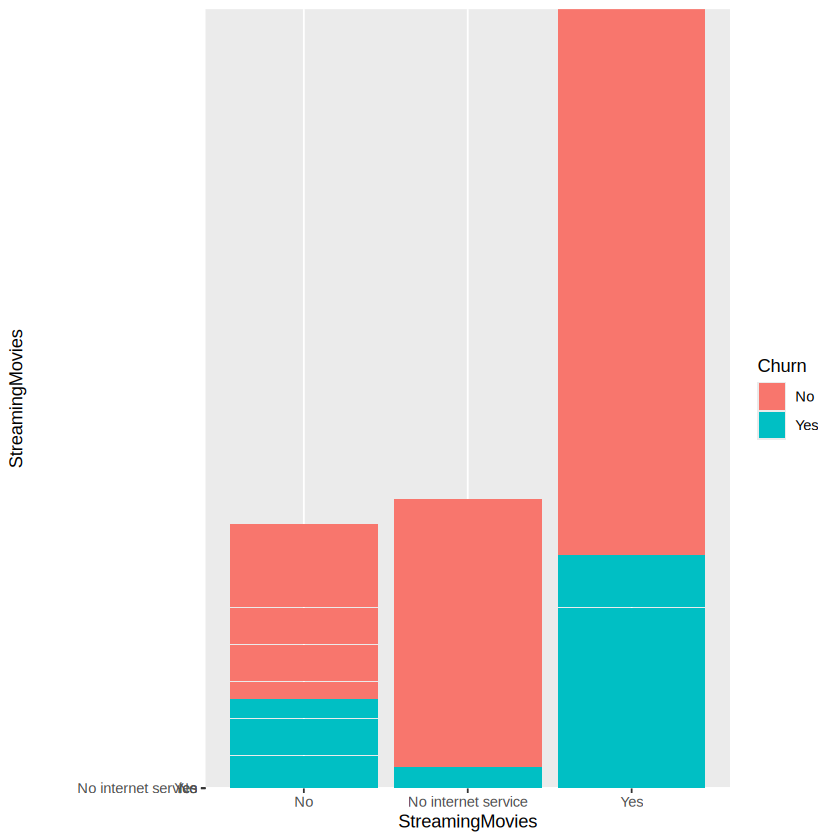

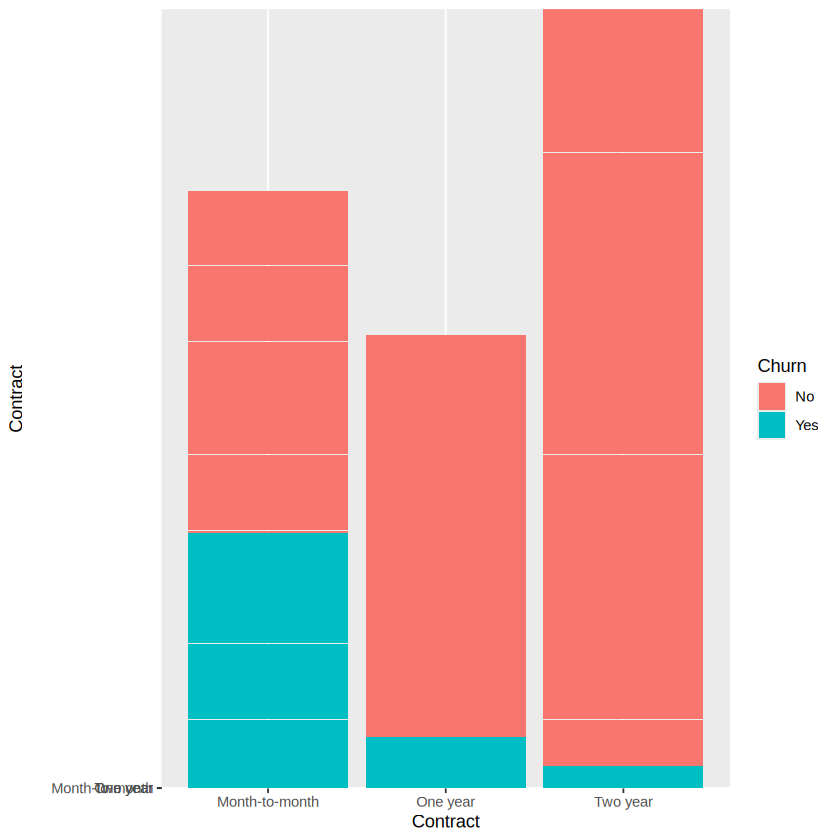

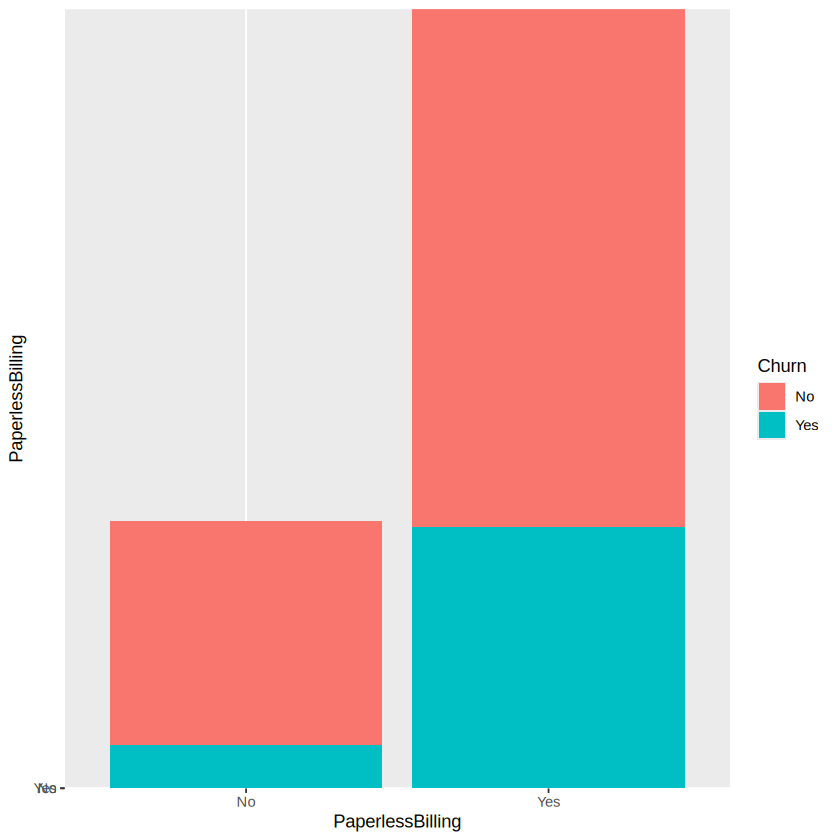

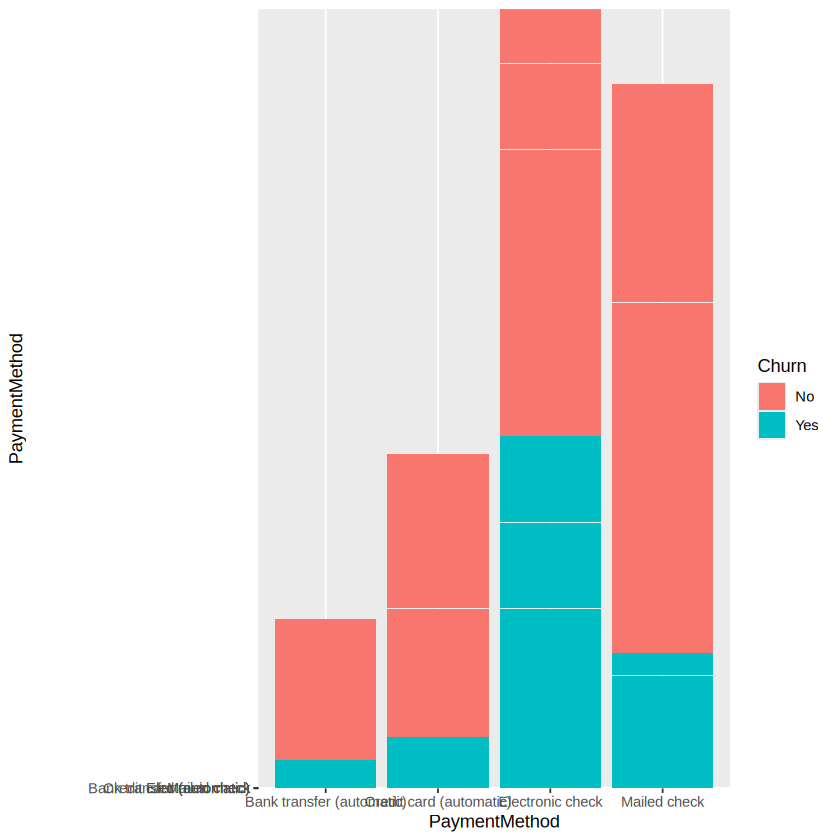

In [10]:
# verificando a classificação de cada variável - categórica(fatores)
ggplot(dados_1, aes(y = gender, x = gender, fill = Churn)) + geom_bar(stat = "identity")

ggplot(dados_1, aes(y = Partner, x = Partner, fill = Churn)) + geom_bar(stat = "identity")

ggplot(dados_1, aes(y = Dependents, x = Dependents, fill = Churn)) + geom_bar(stat = "identity")

ggplot(dados_1, aes(y = PhoneService, x = PhoneService, fill = Churn)) + geom_bar(stat = "identity")

ggplot(dados_1, aes(y = MultipleLines, x = MultipleLines, fill = Churn)) + geom_bar(stat = "identity")

ggplot(dados_1, aes(y = InternetService, x = InternetService, fill = Churn)) + geom_bar(stat = "identity")

ggplot(dados_1, aes(y = OnlineSecurity, x = OnlineSecurity, fill = Churn)) + geom_bar(stat = "identity")

ggplot(dados_1, aes(y = OnlineBackup, x = OnlineBackup, fill = Churn)) + geom_bar(stat = "identity")

ggplot(dados_1, aes(y = DeviceProtection, x = DeviceProtection, fill = Churn)) + geom_bar(stat = "identity")

ggplot(dados_1, aes(y = TechSupport, x = TechSupport, fill = Churn)) + geom_bar(stat = "identity")

ggplot(dados_1, aes(y = StreamingTV, x = StreamingTV, fill = Churn)) + geom_bar(stat = "identity")

ggplot(dados_1, aes(y = StreamingMovies, x = StreamingMovies, fill = Churn)) + geom_bar(stat = "identity")

ggplot(dados_1, aes(y = Contract, x = Contract, fill = Churn)) + geom_bar(stat = "identity")

ggplot(dados_1, aes(y = PaperlessBilling, x = PaperlessBilling, fill = Churn)) + geom_bar(stat = "identity")

ggplot(dados_1, aes(y = PaymentMethod, x = PaymentMethod, fill = Churn)) + geom_bar(stat = "identity")


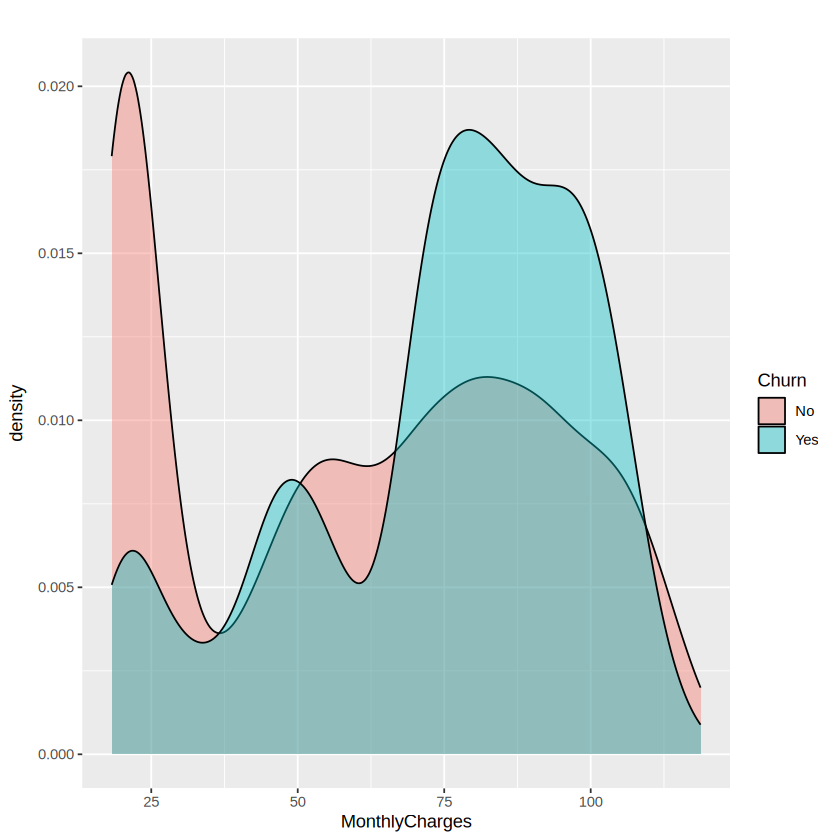

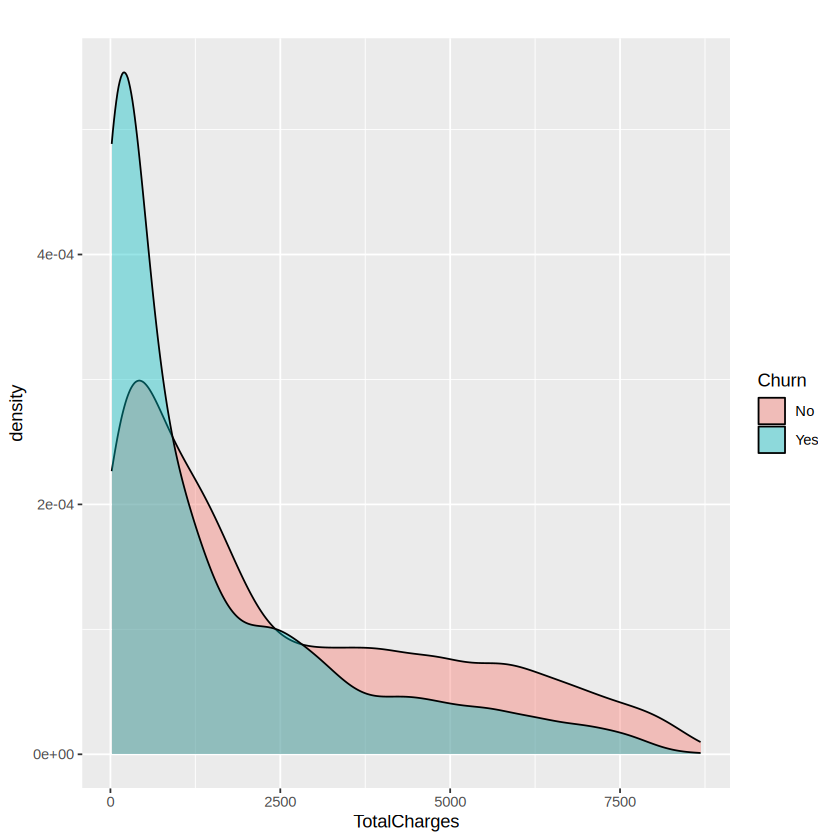

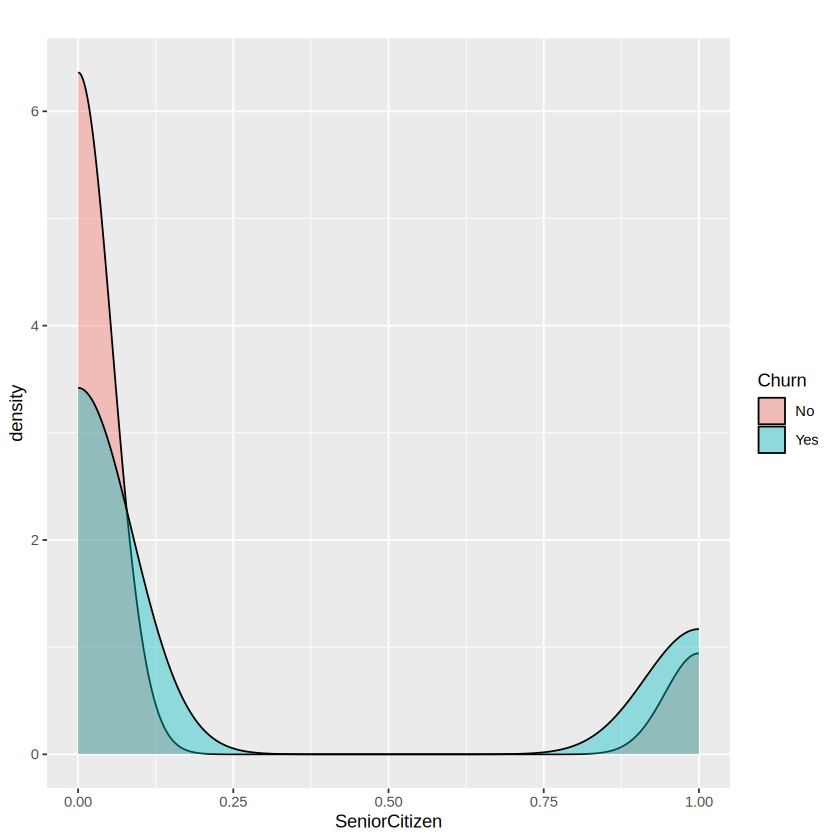

In [11]:
# verificando a classificação de cada variável - numérica
ggplot(dados_1,
aes(x = MonthlyCharges,
fill = Churn)) +
geom_density(alpha = 0.4) +
labs(title = "")

ggplot(dados_1,
aes(x = TotalCharges,
fill = Churn)) +
geom_density(alpha = 0.4) +
labs(title = "")

ggplot(dados_1,
aes(x = SeniorCitizen,
fill = Churn)) +
geom_density(alpha = 0.4) +
labs(title = "")

In [13]:
# transformação de dados (qualitativo para quantitativo) - variáveis binárias
dados_quant <- dados_1
colnames (dados_quant)
dados_quant %>%
mutate(customerID = NULL,
PhoneService = as.factor(ifelse(PhoneService == "Yes",1,0)),
Partner = as.factor(ifelse(Partner == "Yes",1,0)),
Dependents = as.factor(ifelse(Dependents == "Yes",1,0)),
PaperlessBilling = as.factor(ifelse(TechSupport == "Yes",1,0)),
Dependents = as.factor(ifelse(Dependents == "Yes",1,0)),
Churn = as.factor(ifelse(Churn == "Yes",1,0)),
) -> dados_quant
glimpse(dados_quant)

[1] "customerID"       "gender"           "SeniorCitizen"    "Partner"         
 [5] "Dependents"       "tenure"           "PhoneService"     "MultipleLines"   
 [9] "InternetService"  "OnlineSecurity"   "OnlineBackup"     "DeviceProtection"
[13] "TechSupport"      "StreamingTV"      "StreamingMovies"  "Contract"        
[17] "PaperlessBilling" "PaymentMethod"    "MonthlyCharges"   "TotalCharges"    
[21] "Churn"

Rows: 7,032
Columns: 20
$ gender           <fct> Female, Male, Male, Male, Female, Female, Male, Femal…
$ SeniorCitizen    <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ Partner          <fct> 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0,…
$ Dependents       <fct> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ tenure           <int> 1, 34, 2, 45, 2, 8, 22, 10, 28, 62, 13, 16, 58, 49, 2…
$ PhoneService     <fct> 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ MultipleLines    <fct> No phone service, No, No, No phone service, No, Yes, …
$ InternetService  <fct> DSL, DSL, DSL, DSL, Fiber optic, Fiber optic, Fiber o…
$ OnlineSecurity   <fct> No, Yes, Yes, Yes, No, No, No, Yes, No, Yes, Yes, No …
$ OnlineBackup     <fct> Yes, No, Yes, No, No, No, Yes, No, No, Yes, No, No in…
$ DeviceProtection <fct> No, Yes, No, Yes, No, Yes, No, No, Yes, No, No, No in…
$ TechSupport      <fct> No, No, No, Yes, No, No, No, No, Yes, No, No, No inte…
$ StreamingTV   

In [14]:
# utilização de variáveis dummy
dummy_dados <- dados_quant %>% select(InternetService, Contract, PaymentMethod,
                                        MultipleLines, OnlineBackup, OnlineSecurity,
                                        DeviceProtection, StreamingTV,
                                        StreamingMovies, TechSupport)

dummy <- dummyVars(~ ., data = dummy_dados, fullRank = T)

dummy_dados <- predict(dummy, dummy_dados)
dados_quant1 <- bind_cols(dados_quant,dummy_dados)

dados_quant1 %>%
    rename( InternetService.Fiberoptic =`InternetService.Fiber optic`,
            Contract.Oneyear = `Contract.One year`,
            Contract.Twoyear = `Contract.Two year`,
            PaymentMethod.Creditcard = `PaymentMethod.Credit card (automatic)`,
            PaymentMethod.Electronic = `PaymentMethod.Electronic check`,
            PaymentMethod.Mailed = `PaymentMethod.Mailed check`,
            MultipleLines.NoService = `MultipleLines.No phone service`,
            OnlineBackup.NoService = `OnlineBackup.No internet service` ,
            OnlineSecurity.NoService = `OnlineSecurity.No internet service`,
            DeviceProtection.NoService = `DeviceProtection.No internet service`,
            StreamingTV.NoService = `StreamingTV.No internet service`,
            StreamingMovies.NoService = `StreamingMovies.No internet service`,
            TechSupport.NoService = `TechSupport.No internet service`) -> dados_quant1

In [16]:
# exclusao de variaveis qualitativas
dados_quant1 %>%
    mutate(gender = NULL,
            InternetService = NULL,
            Contract = NULL,
            PaymentMethod = NULL,
            PaymentMOnlineBackupethod = NULL,
            OnlineSecurity = NULL,
            StreamingTV = NULL,
            StreamingMovies = NULL,
            MultipleLines = NULL,
            OnlineBackup = NULL,
            DeviceProtection = NULL,
            TechSupport = NULL) -> dados_quant1

glimpse(dados_quant1)

Rows: 7,032
Columns: 30
$ SeniorCitizen              <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ Partner                    <fct> 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0…
$ Dependents                 <fct> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ tenure                     <int> 1, 34, 2, 45, 2, 8, 22, 10, 28, 62, 13, 16,…
$ PhoneService               <fct> 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1…
$ PaperlessBilling           <fct> 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1…
$ MonthlyCharges             <dbl> 29.85, 56.95, 53.85, 42.30, 70.70, 99.65, 8…
$ TotalCharges               <dbl> 29.85, 1889.50, 108.15, 1840.75, 151.65, 82…
$ Churn                      <fct> 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0…
$ InternetService.Fiberoptic <dbl> 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1…
$ InternetService.No         <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0…
$ Contract.Oneyear           <dbl> 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0…
$ Contract.Twoye

Rows: 7,032
Columns: 30
$ SeniorCitizen              <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ Partner                    <dbl> 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1…
$ Dependents                 <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ tenure                     <int> 1, 34, 2, 45, 2, 8, 22, 10, 28, 62, 13, 16,…
$ PhoneService               <dbl> 1, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2…
$ PaperlessBilling           <dbl> 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2…
$ MonthlyCharges             <dbl> 29.85, 56.95, 53.85, 42.30, 70.70, 99.65, 8…
$ TotalCharges               <dbl> 29.85, 1889.50, 108.15, 1840.75, 151.65, 82…
$ Churn                      <dbl> 1, 1, 2, 1, 2, 2, 1, 1, 2, 1, 1, 1, 1, 2, 1…
$ InternetService.Fiberoptic <dbl> 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1…
$ InternetService.No         <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0…
$ Contract.Oneyear           <dbl> 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0…
$ Contract.Twoye

Warning message in cor(dados_num):
“the standard deviation is zero”


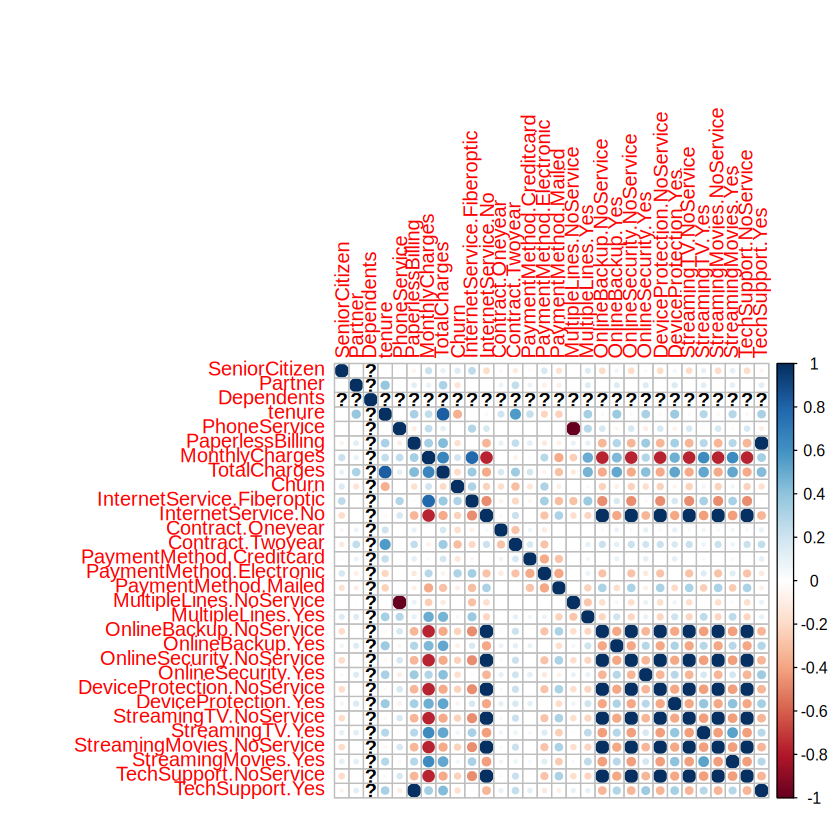

In [18]:
# Correlação dos dados
# todas que estão com <fct> transformar para numérico
dados_quant1 %>%
    mutate( Partner = as.numeric(Partner),
            Dependents = as.numeric(Dependents),
            PhoneService = as.numeric(PhoneService),
            PaperlessBilling = as.numeric(PaperlessBilling),
            Churn = as.numeric(Churn)) -> dados_num

glimpse(dados_num)

corrplot(cor(dados_num), method = "circle")

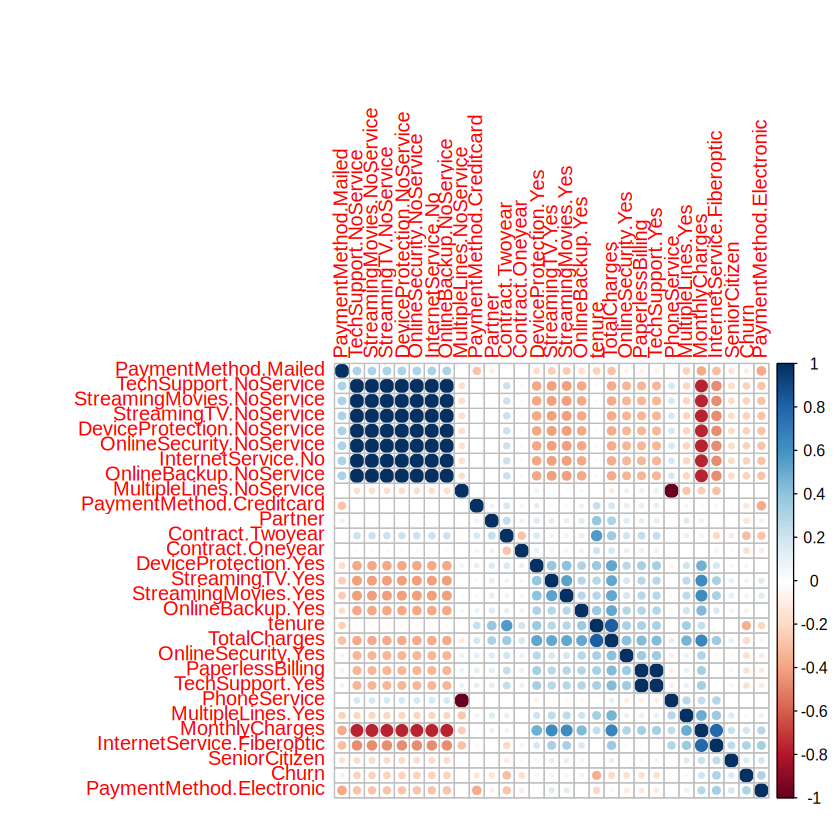

In [19]:
dados_num %>%
    mutate( Dependents = NULL) -> dados_num_1
#glimpse(dados_num_1)

corrplot(cor(dados_num_1),order = "hclust", method = "circle")

In [20]:
dados_num_1 %>%
    mutate( StreamingMovies.NoService = NULL,
            StreamingTV.NoService = NULL,
            DeviceProtection.NoService = NULL ,
            OnlineSecurity.NoService = NULL,
            InternetService.No = NULL,
            OnlineBackup.NoService = NULL ) -> dados_num_1

In [21]:
# balanceamento de base de dados
dados_quant1 %>%
    select(Churn) %>%
    group_by(Churn) %>%
    summarise(n = n())

dados_quant1 %>%
    filter(Churn == 0) %>%
    sample_n(1869) -> dados_quant_0

dados_quant1 %>%
    filter(Churn == 1) -> dados_quant_1

dados_quant_balanc <- bind_rows(dados_quant_0,dados_quant_1)

dados_num_1 %>%
    select(Churn) %>%
    group_by(Churn) %>%
    summarise(n = n())

dados_num_1 %>%
    mutate(Churn = ifelse(Churn == 1,0,1))%>%
    filter(Churn == 0) %>%
    sample_n(1869) -> dados_num_0

dados_num_1 %>%
    mutate(Churn = ifelse(Churn == 1,0,1))%>%
    filter(Churn == 1) -> dados_num_2

dados_num_balanc <- bind_rows(dados_num_2,dados_num_0)

dados_num_balanc %>%
    select(Churn) %>%
    group_by(Churn) %>%
    summarise(n = n())

dados_quant_balanc %>%
    select(Churn) %>%
    group_by(Churn) %>%
    summarise(n = n())

Churn,n
<fct>,<int>
0,5163
1,1869


Churn,n
<dbl>,<int>
1,5163
2,1869


Churn,n
<dbl>,<int>
0,1869
1,1869


Churn,n
<fct>,<int>
0,1869
1,1869


In [22]:
# stepwize
# verificar quais as variaveis agregam ao modelo
modelo_teste1 <- glm(data = dados_num_balanc, Churn ~ .,family=binomial)
step(modelo_teste1)
summary(modelo_teste1)

Start:  AIC=3645.53
Churn ~ SeniorCitizen + Partner + tenure + PhoneService + PaperlessBilling + 
    MonthlyCharges + TotalCharges + InternetService.Fiberoptic + 
    Contract.Oneyear + Contract.Twoyear + PaymentMethod.Creditcard + 
    PaymentMethod.Electronic + PaymentMethod.Mailed + MultipleLines.NoService + 
    MultipleLines.Yes + OnlineBackup.Yes + OnlineSecurity.Yes + 
    DeviceProtection.Yes + StreamingTV.Yes + StreamingMovies.Yes + 
    TechSupport.NoService + TechSupport.Yes


Step:  AIC=3645.53
Churn ~ SeniorCitizen + Partner + tenure + PhoneService + PaperlessBilling + 
    MonthlyCharges + TotalCharges + InternetService.Fiberoptic + 
    Contract.Oneyear + Contract.Twoyear + PaymentMethod.Creditcard + 
    PaymentMethod.Electronic + PaymentMethod.Mailed + MultipleLines.NoService + 
    MultipleLines.Yes + OnlineBackup.Yes + OnlineSecurity.Yes + 
    DeviceProtection.Yes + StreamingTV.Yes + StreamingMovies.Yes + 
    TechSupport.NoService


Step:  AIC=3645.53
Churn ~ Seni


Call:  glm(formula = Churn ~ SeniorCitizen + Partner + tenure + PhoneService + 
    PaperlessBilling + MonthlyCharges + TotalCharges + InternetService.Fiberoptic + 
    Contract.Oneyear + Contract.Twoyear + PaymentMethod.Electronic + 
    MultipleLines.Yes + OnlineBackup.Yes + DeviceProtection.Yes + 
    StreamingTV.Yes + StreamingMovies.Yes + TechSupport.NoService, 
    family = binomial, data = dados_num_balanc)

Coefficients:
               (Intercept)               SeniorCitizen  
                 2.1514378                   0.2804051  
                   Partner                      tenure  
                -0.1634931                  -0.0532423  
              PhoneService            PaperlessBilling  
                 1.3182657                   0.2202560  
            MonthlyCharges                TotalCharges  
                -0.0937728                   0.0002769  
InternetService.Fiberoptic            Contract.Oneyear  
                 3.1125155                  -0.611848


Call:
glm(formula = Churn ~ ., family = binomial, data = dados_num_balanc)

Coefficients: (2 not defined because of singularities)
                             Estimate Std. Error z value Pr(>|z|)    
(Intercept)                 2.267e+00  3.837e-01   5.908 3.45e-09 ***
SeniorCitizen               2.796e-01  1.090e-01   2.566 0.010301 *  
Partner                    -1.668e-01  8.850e-02  -1.885 0.059439 .  
tenure                     -5.467e-02  6.847e-03  -7.985 1.40e-15 ***
PhoneService                1.073e+00  8.186e-01   1.311 0.189769    
PaperlessBilling            1.612e-01  2.276e-01   0.708 0.478782    
MonthlyCharges             -8.149e-02  4.006e-02  -2.034 0.041964 *  
TotalCharges                2.879e-04  7.977e-05   3.610 0.000306 ***
InternetService.Fiberoptic  2.780e+00  1.006e+00   2.764 0.005715 ** 
Contract.Oneyear           -6.056e-01  1.283e-01  -4.720 2.36e-06 ***
Contract.Twoyear           -1.457e+00  1.970e-01  -7.394 1.42e-13 ***
PaymentMethod.Creditcard   -

In [23]:
# Validação cruzada - avalia a capacidade de generalização do modelo
# O método de validação cruzada denominado k-fold consiste em dividir o conjunto total de dados em k subconjuntos mutuamente exclusivos do mesmo tamanho e, a partir daí, um subconjunto é utilizado para teste e os k-1 restantes são utilizados para estimação dos parâmetros, fazendo-se o cálculo da acurácia do modelo. Este processo é realizado k vezes alternando de forma circular o subconjunto de teste.
trainIndex <- createDataPartition(dados_num_balanc$Churn, p = .8, #80 por cento
                                  list = FALSE,
                                  times = 1)

vivoTrain <- dados_num_balanc[ trainIndex,]
vivoTest <- dados_num_balanc[-trainIndex,]

In [24]:
# treinando a base
set.seed(150)

glm_model = train(Churn ~ SeniorCitizen + tenure + PaperlessBilling +
                  MonthlyCharges + TotalCharges + InternetService.Fiberoptic +
                  Contract.Oneyear + Contract.Twoyear + PaymentMethod.Electronic +
                  MultipleLines.Yes + OnlineSecurity.Yes + StreamingTV.Yes +
                  StreamingMovies.Yes + TechSupport.NoService,
                  data= vivoTrain,
                  method= "glm",
                  trControl = trainControl(method = "cv"),
                  family = "binomial")

summary(glm_model)
varImp(glm_model)

Warning message in train.default(x, y, weights = w, ...):
“You are trying to do regression and your outcome only has two possible values Are you trying to do classification? If so, use a 2 level factor as your outcome column.”



Call:
NULL

Coefficients:
                             Estimate Std. Error z value Pr(>|z|)    
(Intercept)                 1.904e+00  3.698e-01   5.150 2.60e-07 ***
SeniorCitizen               2.466e-01  1.214e-01   2.031 0.042287 *  
tenure                     -5.445e-02  7.618e-03  -7.148 8.79e-13 ***
PaperlessBilling           -1.393e-02  1.298e-01  -0.107 0.914525    
MonthlyCharges             -2.851e-02  8.224e-03  -3.467 0.000526 ***
TotalCharges                2.513e-04  8.998e-05   2.792 0.005231 ** 
InternetService.Fiberoptic  1.395e+00  2.702e-01   5.163 2.42e-07 ***
Contract.Oneyear           -6.066e-01  1.434e-01  -4.230 2.33e-05 ***
Contract.Twoyear           -1.535e+00  2.261e-01  -6.787 1.15e-11 ***
PaymentMethod.Electronic    3.676e-01  9.861e-02   3.728 0.000193 ***
MultipleLines.Yes           4.388e-01  1.271e-01   3.451 0.000558 ***
OnlineSecurity.Yes         -3.571e-01  1.245e-01  -2.868 0.004131 ** 
StreamingTV.Yes             5.373e-01  1.387e-01   3.872 0.0001

glm variable importance

                           Overall
tenure                      100.00
TechSupport.NoService        96.65
Contract.Twoyear             94.87
InternetService.Fiberoptic   71.81
StreamingMovies.Yes          58.75
Contract.Oneyear             58.56
StreamingTV.Yes              53.47
PaymentMethod.Electronic     51.42
MonthlyCharges               47.72
MultipleLines.Yes            47.50
OnlineSecurity.Yes           39.21
TotalCharges                 38.14
SeniorCitizen                27.32
PaperlessBilling              0.00

In [25]:
# testando a base

reg_log_pred <- predict(glm_model,vivoTrain)
reg_log_pred1 <- data.frame(reg_log_pred)
reg_log_pred1$reg_log_pred <- as.factor(ifelse(reg_log_pred1$reg_log_pred >= 0.5,1,0))
reg_log_pred1$reg_log_pred <- as.factor(ifelse(reg_log_pred1$reg_log_pred == 1,"evadido","cliente"))
vivoTrain$Churn <- as.factor(vivoTrain$Churn)
vivoTrain$Churn <- as.factor(ifelse(vivoTrain$Churn == 1,"evadido","cliente"))
glimpse(reg_log_pred1)

matrix_reg <-
confusionMatrix(data = reg_log_pred1$reg_log_pred, reference = vivoTrain$Churn, positive = "evadido")
matrix_reg$table

metricas <- data.frame(matrix_reg$byClass)

Rows: 2,992
Columns: 1
$ reg_log_pred <fct> cliente, evadido, evadido, evadido, evadido, cliente, eva…


          Reference
Prediction cliente evadido
   cliente    1089     286
   evadido     407    1210

In [27]:
glimpse(dados_1)
# excluir o ID
# transformar em qualitativa as quantitativas
# adicionar classes as variáveis numericas

dados_1 %>%
    mutate (SeniorCitizen = as.factor(ifelse(SeniorCitizen == 1, "Yes", "No")),
            customerID = NULL) -> dados_quali

Rows: 7,032
Columns: 21
$ customerID       <fct> 7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOCW, 9237-…
$ gender           <fct> Female, Male, Male, Male, Female, Female, Male, Femal…
$ SeniorCitizen    <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ Partner          <fct> Yes, No, No, No, No, No, No, No, Yes, No, Yes, No, Ye…
$ Dependents       <fct> No, No, No, No, No, No, Yes, No, No, Yes, Yes, No, No…
$ tenure           <int> 1, 34, 2, 45, 2, 8, 22, 10, 28, 62, 13, 16, 58, 49, 2…
$ PhoneService     <fct> No, Yes, Yes, No, Yes, Yes, Yes, No, Yes, Yes, Yes, Y…
$ MultipleLines    <fct> No phone service, No, No, No phone service, No, Yes, …
$ InternetService  <fct> DSL, DSL, DSL, DSL, Fiber optic, Fiber optic, Fiber o…
$ OnlineSecurity   <fct> No, Yes, Yes, Yes, No, No, No, Yes, No, Yes, Yes, No …
$ OnlineBackup     <fct> Yes, No, Yes, No, No, No, Yes, No, No, Yes, No, No in…
$ DeviceProtection <fct> No, Yes, No, Yes, No, Yes, No, No, Yes, No, No, No in…
$ TechSupport   

In [28]:
# criando classes para as variaveis quantitativas
tenure <- summary(dados_quali$tenure)
tenure

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1.00    9.00   29.00   32.42   55.00   72.00 

In [29]:
TotalCharges <- summary(dados_quali$TotalCharges)
min_TotalCharges <- TotalCharges[[1]]-5
q1_TotalCharges <- TotalCharges[[2]]
q2_TotalCharges <- TotalCharges[[3]]
q3_TotalCharges <- TotalCharges[[5]]
max_TotalCharges <- TotalCharges[[6]]+5

dados_quali %>%
    mutate( TotalCharges = cut(TotalCharges, breaks = c(min_TotalCharges,
            q1_TotalCharges,
            q2_TotalCharges,
            q3_TotalCharges,
            max_TotalCharges)) ) -> dados_quali

summary(dados_quali$TotalCharges)

(13.8,401]       (401,1.4e+03]  (1.4e+03,3.79e+03] (3.79e+03,8.69e+03] 
               1758                1758                1758                1758

In [30]:
# balanceamento da base
glimpse(dados_quali)
dados_quali %>%
    select(Churn) %>%
    group_by(Churn) %>%
    summarise(n = n())

dados_quali %>%
    filter(Churn == "No") %>%
    sample_n(1869) -> dados_quali_no

dados_quali %>%
    filter(Churn == "Yes") -> dados_quali_yes

dados_quali_balanc <- bind_rows(dados_quali_no,dados_quali_yes)

dados_quali_balanc %>%
    select(Churn) %>%
    group_by(Churn) %>%
    summarise(n = n())

Rows: 7,032
Columns: 20
$ gender           <fct> Female, Male, Male, Male, Female, Female, Male, Femal…
$ SeniorCitizen    <fct> No, No, No, No, No, No, No, No, No, No, No, No, No, N…
$ Partner          <fct> Yes, No, No, No, No, No, No, No, Yes, No, Yes, No, Ye…
$ Dependents       <fct> No, No, No, No, No, No, Yes, No, No, Yes, Yes, No, No…
$ tenure           <int> 1, 34, 2, 45, 2, 8, 22, 10, 28, 62, 13, 16, 58, 49, 2…
$ PhoneService     <fct> No, Yes, Yes, No, Yes, Yes, Yes, No, Yes, Yes, Yes, Y…
$ MultipleLines    <fct> No phone service, No, No, No phone service, No, Yes, …
$ InternetService  <fct> DSL, DSL, DSL, DSL, Fiber optic, Fiber optic, Fiber o…
$ OnlineSecurity   <fct> No, Yes, Yes, Yes, No, No, No, Yes, No, Yes, Yes, No …
$ OnlineBackup     <fct> Yes, No, Yes, No, No, No, Yes, No, No, Yes, No, No in…
$ DeviceProtection <fct> No, Yes, No, Yes, No, Yes, No, No, Yes, No, No, No in…
$ TechSupport      <fct> No, No, No, Yes, No, No, No, No, Yes, No, No, No inte…
$ StreamingTV   

Churn,n
<fct>,<int>
No,5163
Yes,1869


Churn,n
<fct>,<int>
No,1869
Yes,1869


In [32]:
# separação da base para teste e treino
trainIndex_quali <- createDataPartition(dados_quali_balanc$Churn, p = .8,
                                        list = FALSE,
                                        times = 1)

vivoTrain_quali <- dados_quali_balanc[ trainIndex_quali,]
vivoTest_quali <- dados_quali_balanc[-trainIndex_quali,]

In [33]:
# treinando o modelo de árvore de decisão
vivo.tree = train(Churn ~ .,
                  data= vivoTrain_quali,
                  method="rpart",
                  trControl = trainControl(method = "cv"))

In [34]:
vivo.tree

CART 

2992 samples
  19 predictor
   2 classes: 'No', 'Yes' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 2693, 2693, 2693, 2692, 2694, 2692, ... 
Resampling results across tuning parameters:

  cp          Accuracy   Kappa    
  0.02707219  0.7369593  0.4739454
  0.17914439  0.6821463  0.3643306
  0.28877005  0.5521697  0.1060105

Accuracy was used to select the optimal model using the largest value.
The final value used for the model was cp = 0.02707219.

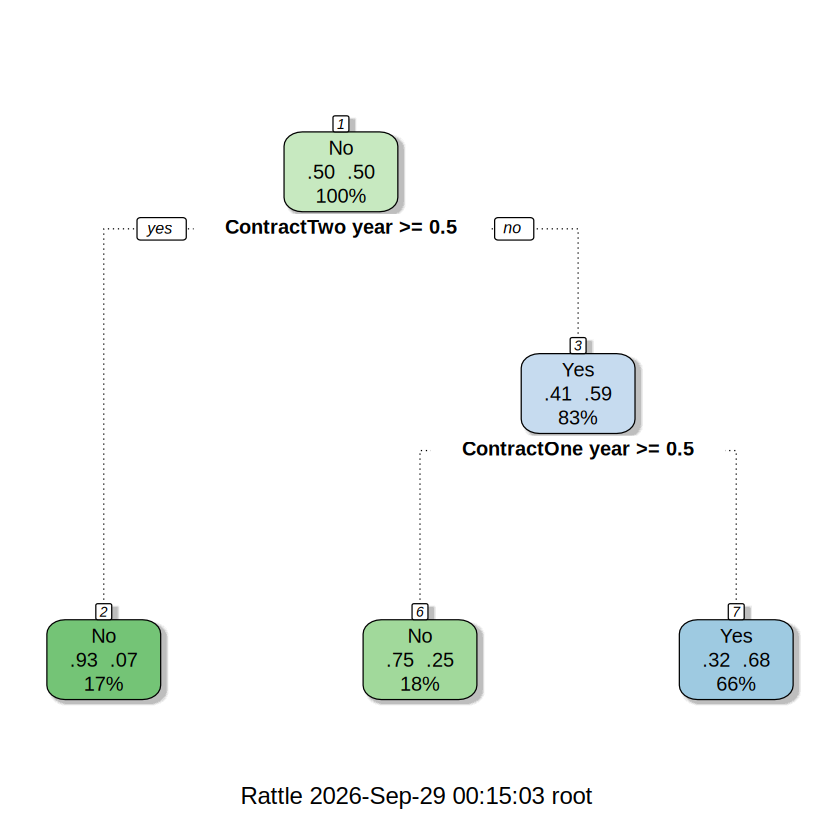

In [35]:
fancyRpartPlot(vivo.tree$finalModel)

In [37]:
vivo.pred = predict(vivo.tree, newdata = vivoTrain_quali)

In [38]:
matrix_tree <- confusionMatrix(data = vivo.pred, reference = vivoTrain_quali$Churn, positive = "Yes")
matrix_tree$table

          Reference
Prediction   No  Yes
       No   862  162
       Yes  634 1334

In [39]:
metricas_tree <- data.frame(matrix_tree$byClass)
metricas_tree

,matrix_tree.byClass
,<dbl>
Sensitivity,0.8917112
Specificity,0.5762032
Pos Pred Value,0.6778455
Neg Pred Value,0.8417969
Precision,0.6778455
Recall,0.8917112
F1,0.7702079
Prevalence,0.5000000
Detection Rate,0.4458556
